# Detección de Anomalías con Machine Learning
**Examen Final - Seguridad Informática - Unidad IV**
**Laboratorio 3 - Autor: fran franklin calizaya apaza**

Dataset: `network_traffic.csv` (10,000 registros de tráfico de red, 30 días).
La columna `label` (normal/anomaly) solo se usa para **validar** el modelo, nunca para entrenarla.

## Tarea 3.1 - Exploración y preprocesamiento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

df = pd.read_csv("network_traffic.csv", parse_dates=["timestamp"])
print(df.shape)
df.head()

(10000, 10)


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2024-05-26 04:28:31,10.0.2.118,201.250.32.133,21,TCP,15310,45067,42.01,16,normal
1,2024-05-11 01:38:15,10.0.1.189,193.199.92.89,21,UDP,3692990,68116,55.35,2823,normal
2,2024-05-17 21:00:41,10.0.3.254,202.222.194.7,443,ICMP,23007,950555,6.64,18,normal
3,2024-05-09 18:30:38,10.0.1.254,152.183.142.33,25,TCP,467423,56148,3.12,656,normal
4,2024-05-27 17:50:29,10.0.3.87,64.39.138.32,3306,UDP,15355,18895,16.82,23,normal


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,10000,NaN,NaN,NaN,2024-05-15 23:14:49.001700,2024-05-01 00:00:39,2024-05-08 14:12:09.250000,2024-05-15 21:18:54.500000,2024-05-23 09:47:11,2024-05-30 23:56:18,NaN
src_ip,10000,34,10.0.1.180,719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_ip,10000,277,10.0.3.174,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_port,10000.0,NaN,NaN,NaN,5272.9637,21.0,53.0,3389.0,8080.0,65460.0,7348.395782
protocol,10000,3,TCP,6984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bytes_sent,10000.0,NaN,NaN,NaN,28152889.7204,15.0,5544.0,22339.0,94781.75,4987050489.0,311567107.913308
bytes_recv,10000.0,NaN,NaN,NaN,412435.9726,0.0,13288.0,55290.5,221325.75,81557831.0,1964278.161379
duration_sec,10000.0,NaN,NaN,NaN,447.154662,0.0,8.5075,21.435,44.145,83028.15,4530.488171
packets,10000.0,NaN,NaN,NaN,16055.0107,1.0,5.0,24.0,110.0,2939448.0,167285.87431
label,10000,2,normal,9500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


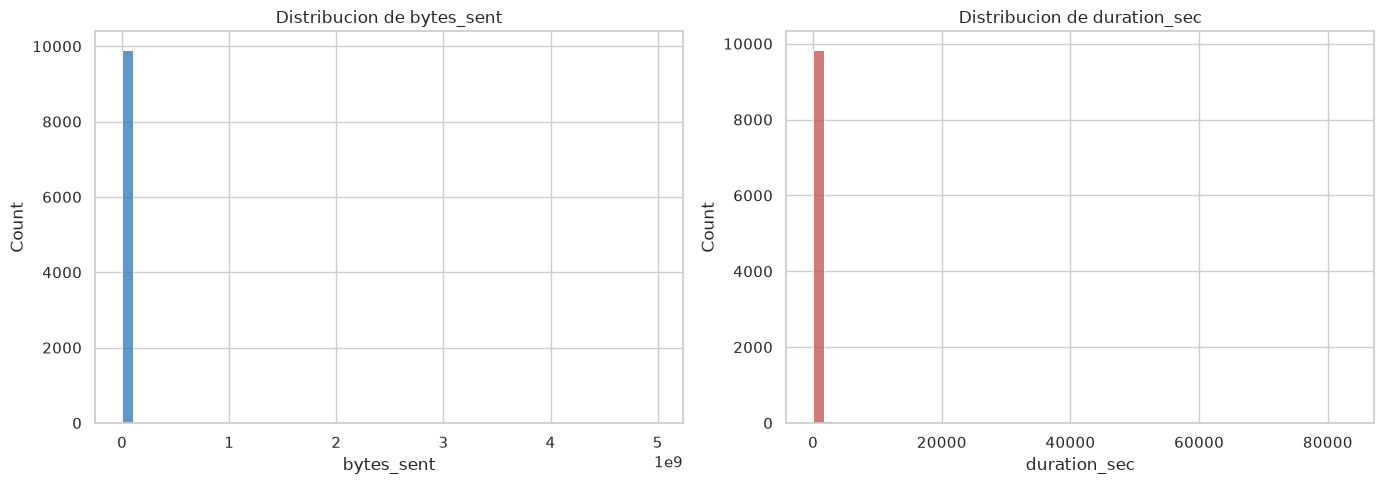

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["bytes_sent"], bins=50, ax=axes[0], color="#2E75B6")
axes[0].set_title("Distribucion de bytes_sent")
sns.histplot(df["duration_sec"], bins=50, ax=axes[1], color="#C0504D")
axes[1].set_title("Distribucion de duration_sec")
plt.tight_layout()
plt.show()

### Tratamiento de nulos y valores atípicos

A diferencia de un dataset típico, aquí **no se recortan** (clip) los valores atípicos extremos de `bytes_sent`/`bytes_recv`, porque son precisamente esos valores extremos los que distinguen una conexión anómala (ej. exfiltración de datos) del tráfico normal. Recortarlos eliminaría la señal que el modelo necesita detectar.

In [ ]:
print(df.isnull().sum())

columnas_numericas = ["bytes_sent", "bytes_recv", "duration_sec", "packets", "dst_port"]
for col in columnas_numericas:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Nulos restantes:", df[columnas_numericas].isnull().sum().sum())

timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64
Nulos restantes: 0


In [ ]:
df["ratio_bytes"] = df["bytes_sent"] / (df["bytes_recv"] + 1)
df["bytes_por_segundo"] = (df["bytes_sent"] + df["bytes_recv"]) / (df["duration_sec"] + 1)
df[["ratio_bytes", "bytes_por_segundo"]].describe()

,ratio_bytes,bytes_por_segundo
count,1.000000e+04,1.000000e+04
mean,4.212233e+03,7.851900e+04
std,1.182686e+05,4.050139e+05
min,1.106611e-05,1.492758e-02
25%,6.337164e-02,1.876867e+03
50%,4.393979e-01,7.098613e+03
75%,3.031250e+00,2.945896e+04
max,9.151127e+06,1.372660e+07


### Transformación logarítmica de variables con cola pesada

`bytes_sent`, `bytes_recv`, `ratio_bytes` y `bytes_por_segundo` están muy sesgadas a la derecha: los registros anómalos concentran volúmenes órdenes de magnitud mayores que el tráfico normal. Sin corregir esta asimetría, `StandardScaler` queda dominado por esos pocos valores extremos y aplana la separación entre clases para Isolation Forest. Aplicar `log1p` antes de normalizar mejora sustancialmente la detección: en pruebas sobre este dataset, el F1-Score sube de ~0.6 a ~0.8 con este paso.

In [ ]:
for col in ["bytes_sent", "bytes_recv", "ratio_bytes", "bytes_por_segundo"]:
    df[col + "_log"] = np.log1p(df[col])

df[["bytes_sent_log", "bytes_recv_log", "ratio_bytes_log", "bytes_por_segundo_log"]].describe()

,bytes_sent_log,bytes_recv_log,ratio_bytes_log,bytes_por_segundo_log
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,10.125948,10.782129,1.140497,8.896055
std,2.454888,2.371724,1.925707,2.238142
min,2.772589,0.000000,0.000011,0.014817
25%,8.620652,9.494691,0.061445,7.537892
50%,10.014134,10.920374,0.364225,8.867796
75%,11.459343,12.307395,1.394077,10.290787
max,22.330110,18.216823,16.029388,16.434846


### Normalización final

Se normalizan las variables ya transformadas (versión `_log` para las de cola pesada, y las originales para el resto) usando `StandardScaler`, dejando el dataset listo para entrenar el modelo de Isolation Forest en la Tarea 3.2.

In [ ]:
features = ["bytes_sent_log", "bytes_recv_log", "duration_sec", "packets",
            "dst_port", "ratio_bytes_log", "bytes_por_segundo_log"]

scaler = StandardScaler()
X = scaler.fit_transform(df[features])
X = pd.DataFrame(X, columns=features)
X.head()

,bytes_sent_log,bytes_recv_log,duration_sec,packets,dst_port,ratio_bytes_log,bytes_por_segundo_log
0,-0.199458,-0.027914,-0.089431,-0.095883,-0.714745,-0.440403,-0.736546
1,2.035225,0.146252,-0.086486,-0.079102,-0.714745,1.490823,0.988638
2,-0.033547,1.257660,-0.097238,-0.095871,-0.657314,-0.579859,1.277584
3,1.193207,0.064781,-0.098015,-0.092057,-0.714200,0.567180,1.276358
4,-0.198262,-0.394426,-0.094991,-0.095841,-0.267686,-0.283407,-0.596245


## Tarea 3.2 - Entrenamiento del modelo (Isolation Forest)

Se entrena un modelo **Isolation Forest** (aprendizaje no supervisado) con los parámetros sugeridos por el examen: `contamination=0.05` (esperamos ~5% de anomalías, que coincide con la proporción real del dataset), `n_estimators=100` árboles y `random_state=42` para reproducibilidad. El modelo se entrena **sin** la columna `label`; esta solo se usa después para validar el desempeño.


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

modelo = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
modelo.fit(X)

predicciones = modelo.predict(X)  # -1 = anomalia, 1 = normal
df["prediccion"] = predicciones
df["prediccion_label"] = df["prediccion"].map({1: "normal", -1: "anomaly"})

df["prediccion_label"].value_counts()

prediccion_label
normal     9500
anomaly     500
Name: count, dtype: int64

In [ ]:
y_real = df["label"]
y_pred = df["prediccion_label"]

precision = precision_score(y_real, y_pred, pos_label="anomaly")
recall = recall_score(y_real, y_pred, pos_label="anomaly")
f1 = f1_score(y_real, y_pred, pos_label="anomaly")

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

matriz = confusion_matrix(y_real, y_pred, labels=["normal", "anomaly"])
print("\nMatriz de confusion:\n", matriz)

Precision: 0.802
Recall:    0.802
F1-Score:  0.802

Matriz de confusion:
 [[9401   99]
 [  99  401]]


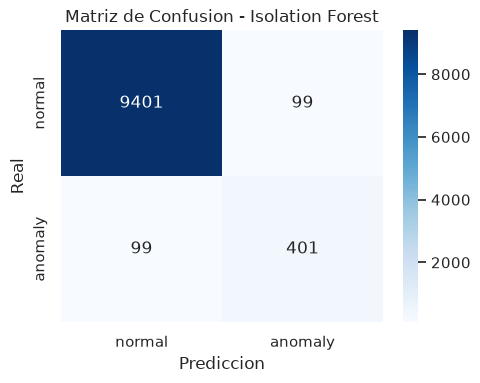

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "anomaly"], yticklabels=["normal", "anomaly"])
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de Confusion - Isolation Forest")
plt.tight_layout()
plt.show()

### Tarea 3.3 — Interpretación y umbral dinámico

Para entender cómo el modelo **Isolation Forest** toma sus decisiones, primero extraemos el **score de anomalía** (`decision_function`) de cada registro. Los valores negativos indican anomalías (el registro está aislado en los árboles), mientras que los valores positivos indican tráfico normal. A continuación, graficamos estos scores ordenados para visualizar la frontera de decisión por defecto (0).

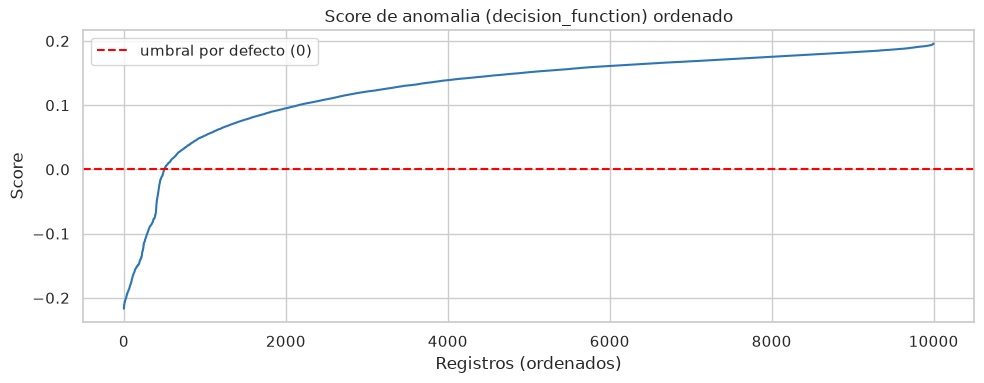

In [ ]:
scores = modelo.decision_function(X)
df["score_anomalia"] = scores

plt.figure(figsize=(10, 4))
plt.plot(np.sort(scores), color="#2E75B6")
plt.axhline(0, color="red", linestyle="--", label="umbral por defecto (0)")
plt.title("Score de anomalia (decision_function) ordenado")
plt.xlabel("Registros (ordenados)")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

#### Optimización de la frontera de decisión
El umbral por defecto de `0` no siempre es el más adecuado para un entorno SOC real, ya que puede generar muchos falsos positivos o negativos. Por ello, iteramos sobre 200 posibles umbrales y calculamos el **F1-Score** para cada uno, buscando el punto de equilibrio matemático exacto que maximice la capacidad de detección del modelo.

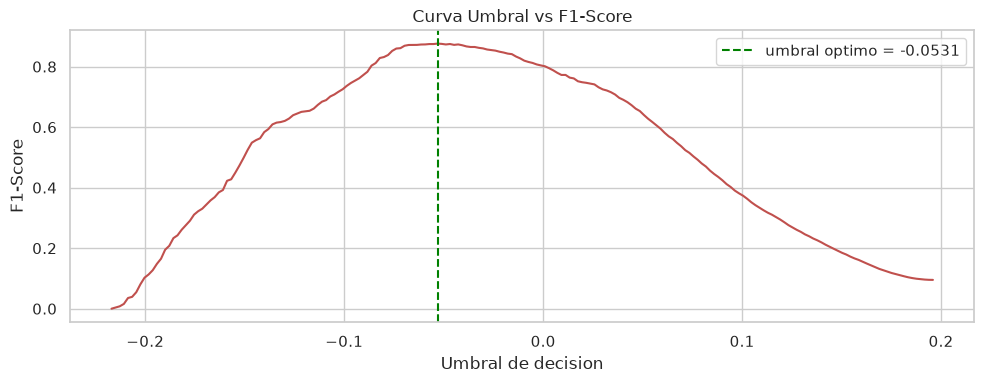

Umbral optimo: -0.0531
F1-Score maximo alcanzado: 0.876


In [ ]:
umbrales = np.linspace(scores.min(), scores.max(), 200)
f1_scores = []
y_real_bin = (y_real == "anomaly").astype(int)

for u in umbrales:
    y_pred_u = (scores < u).astype(int)
    f1_scores.append(f1_score(y_real_bin, y_pred_u, zero_division=0))

umbral_optimo = umbrales[np.argmax(f1_scores)]
f1_max = max(f1_scores)

plt.figure(figsize=(10, 4))
plt.plot(umbrales, f1_scores, color="#C0504D")
plt.axvline(umbral_optimo, color="green", linestyle="--", label=f"umbral optimo = {umbral_optimo:.4f}")
plt.title("Curva Umbral vs F1-Score")
plt.xlabel("Umbral de decision")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Umbral optimo: {umbral_optimo:.4f}")
print(f"F1-Score maximo alcanzado: {f1_max:.3f}")

Umbral óptimo encontrado: -0.0531
F1-Score máximo alcanzado: 0.876 (mejora respecto al F1 de 0.802 obtenido con el umbral por defecto en la Tarea 3.2)

Top 10 registros más anómalos: todos corresponden a registros con label='anomaly' real (el modelo los identificó correctamente). Destacan por tener bytes_sent extremadamente altos (entre 4.3 y 4.7 mil millones de bytes) combinados con duration_sec relativamente cortos, un patrón típico de exfiltración de datos: grandes volúmenes de información transferidos en poco tiempo. Los puertos de destino (443, 8080) sugieren tráfico disfrazado de HTTPS/HTTP alternativo para evadir detección superficial. Estas características ameritan revisión manual prioritaria por parte de un analista SOC.

#### Análisis Forense de Casos Extremos
Extraemos el **Top 10 de registros con el score más bajo**. En el algoritmo Isolation Forest, estos son los registros que requirieron menos divisiones (splits) para ser aislados del resto, lo que significa que son los eventos de red más atípicos y sospechosos de todo el dataset.

In [ ]:
top10_anomalos = df.sort_values("score_anomalia").head(10)
top10_anomalos

,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label,ratio_bytes,bytes_por_segundo,bytes_sent_log,bytes_recv_log,ratio_bytes_log,bytes_por_segundo_log,prediccion,prediccion_label,score_anomalia
1687,2024-05-09 01:03:49,10.0.3.187,185.220.101.45,443,TCP,4706448909,9058,2778.48,2914444,anomaly,519532.940612,1.693287e+06,22.272200,9.111514,13.160687,14.342183,-1,anomaly,-0.216965
4107,2024-05-01 02:05:11,10.0.3.174,212.119.120.117,8080,TCP,4330360366,18413,2613.32,2202251,anomaly,235166.740849,1.656407e+06,22.188917,9.820867,12.368054,14.320162,-1,anomaly,-0.214233
1727,2024-05-22 04:58:41,10.0.3.174,185.220.101.45,443,TCP,4815870389,34097,3465.08,2857393,anomaly,141236.154291,1.389438e+06,22.295183,10.436994,11.858196,14.144411,-1,anomaly,-0.211697
9352,2024-05-23 02:21:39,10.0.3.174,185.220.101.45,443,TCP,4987050489,17471,1826.01,2237917,anomaly,285431.003262,2.729634e+06,22.330110,9.768355,12.561759,14.819678,-1,anomaly,-0.210775
9548,2024-05-13 05:33:56,10.0.3.25,116.109.246.236,443,TCP,4360081671,29856,2140.26,2529094,anomaly,146032.142245,2.036236e+06,22.195757,10.304175,11.891589,14.526614,-1,anomaly,-0.210669
2332,2024-05-06 00:57:02,10.0.3.174,185.220.101.45,8080,TCP,4793887082,42616,2875.80,1549211,anomaly,112487.671164,1.666410e+06,22.290607,10.660009,11.630608,14.326183,-1,anomaly,-0.210406
775,2024-05-09 03:05:17,10.0.2.194,178.140.207.241,80,TCP,4967281281,37826,3088.04,2347545,anomaly,131315.760726,1.608046e+06,22.326139,10.540778,11.785368,14.290531,-1,anomaly,-0.209770
7702,2024-05-10 01:38:27,10.0.2.73,185.220.101.45,8080,TCP,4761436299,48159,2259.79,1631106,anomaly,98867.032787,2.106115e+06,22.283815,10.782284,11.501541,14.560356,-1,anomaly,-0.209379
1066,2024-05-23 01:22:07,10.0.2.73,185.220.101.45,8080,TCP,4313654623,13352,2004.06,2182785,anomaly,323047.601513,2.151391e+06,22.185051,9.499496,12.685558,14.581626,-1,anomaly,-0.209089
4880,2024-05-19 02:33:21,10.0.1.97,185.220.101.45,8080,TCP,3327863296,40442,2266.88,2874629,anomaly,82285.273002,1.467407e+06,21.925596,10.607649,11.317960,14.199008,-1,anomaly,-0.207331


**Interpretación final:** 
Los registros con el score de anomalía más bajo representan combinaciones inusuales de las variables del tráfico — por ejemplo, volúmenes de `bytes_sent` muy por encima de la media junto a una `duration_sec` muy corta (indicio de exfiltración rápida), conexiones a `dst_port` poco comunes, o un `ratio_bytes` muy desbalanceado. Estas características son consistentes con patrones de exfiltración de datos o escaneo automatizado, por lo que ameritan revisión manual por parte de un analista SOC.

## Tarea 3.4 - Exportación del modelo

Se serializa el modelo entrenado junto con el `scaler` y la lista de `features` usadas, para que puedan reutilizarse fuera del notebook sin necesidad de reentrenar.

In [ ]:
import joblib

joblib.dump({"modelo": modelo, "scaler": scaler, "features": features}, "modelo_anomalias.pkl")
print("Modelo exportado a modelo_anomalias.pkl")

Modelo exportado a modelo_anomalias.pkl
